# Module 1: NLP Analysis of Emotional Complexity
## Cinematic Speech as a Stress Test for Facial Animation Systems

**Author:** Alex Argese  
**Date:** April 2026

This notebook quantifies the affective gap between VOCASET — the dominant benchmark
in speech-driven 3D facial animation — and a curated Disney Cinematic Corpus (DCC)
of 73 dialogues from seven animated films.

The analysis combines automated emotion classification with human annotation to:
1. Compare the emotional distribution of the two corpora
2. Evaluate human-model agreement on cinematic dialogue
3. Identify systematic failure modes of text-based emotion classifiers

**Model:** `j-hartmann/emotion-english-distilroberta-base` (DistilRoBERTa, 7 Ekman categories)  
**Datasets:** VOCASET (480 sentences, MPI-IS) · Disney Cinematic Corpus (73 dialogues, manually annotated)

In [ ]:
import zipfile
import os
import pandas as pd

with zipfile.ZipFile('sentencestext.zip', 'r') as z:
    z.extractall('vocaset_sentences')

sentences = []
folder = 'vocaset_sentences/sentencestext'
for filename in os.listdir(folder):
    if filename.endswith('.txt'):
        subject = filename.replace('.txt', '')
        with open(os.path.join(folder, filename), 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    sentences.append({'subject': subject, 'sentence': line})

df_voca = pd.DataFrame(sentences)
print(f"Total number VOCASET: {len(df_voca)}")
print(df_voca['sentence'].head(20))

Total number VOCASET: 480
0     She had your dark suit in greasy wash water al...
1          Don't ask me to carry an oily rag like that.
2     Are those shy Eurasian footwear, cowboy chaps,...
3     With tenure, Suzie’d have all the more pleasur...
4                  NBC glad. Why? Fox TV jerks quiz PM.
5              Curiosity and mediocrity seldom coexist.
6     Special task forces rescue hostages from kidna...
7     Nonprofit organizations have frequent fund rai...
8             Mosquitoes exist in warm, humid climates.
9     The previous speaker presented ambiguous results.
10             Just drop notices in any suggestion box.
11    Military personnel are expected to obey govern...
12    Chip postponed alimony payments until the late...
13               Those musicians harmonize marvelously.
14     Correct execution of my instructions is crucial.
15      Iris thinks this zoo has eleven Spanish zebras.
16       Barb's gold bracelet was a graduation present.
17       Renaissance h

In [ ]:
!pip install transformers spacy --quiet
!python -m spacy download en_core_web_sm --quiet

import pandas as pd
from transformers import pipeline

# Load the emotion classifier
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

print("✓ Setup completed")
print(f"VOCASET phrases uploaded: {len(df_voca)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 63.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Setup completed
VOCASET phrases uploaded: 480


---
## 1. Setup and Data Loading

### 1.1 VOCASET
VOCASET is loaded from the official dataset files. After deduplication, 256 unique
sentences remain out of 480 total (224 are exact cross-subject duplicates).

### 1.2 Disney Cinematic Corpus (DCC)
73 dialogues manually curated from official screenplays of 7 Disney/Pixar films.
Each dialogue is annotated with a fine-grained emotion label by the author.

In [ ]:
disney_dialogues = [

    # FROZEN - from official screenplay (Jennifer Lee, 9/23/13)
    {"film": "Frozen", "character": "Hans", "emotion_label": "betrayal",
     "text": "Oh Anna. If only there was someone out there who loved you."},
    {"film": "Frozen", "character": "Elsa", "emotion_label": "fear",
     "text": "No. Don't touch me. I don't want to hurt you."},
    {"film": "Frozen", "character": "Anna", "emotion_label": "desperation",
     "text": "Elsa, please. Please. I can't live like this anymore."},
    {"film": "Frozen", "character": "Anna", "emotion_label": "heartbreak",
     "text": "What did I ever do to you?! Why do you shut me out? Why do you shut the world out? What are you so afraid of?!"},
    {"film": "Frozen", "character": "Elsa", "emotion_label": "vulnerability",
     "text": "...Then leave."},
    {"film": "Frozen", "character": "Elsa", "emotion_label": "repression",
     "text": "Conceal. Don't feel. Put on a show. Make one wrong move and everyone will know."},
    {"film": "Frozen", "character": "Elsa", "emotion_label": "fear",
     "text": "I'm scared. It's getting stronger."},
    {"film": "Frozen", "character": "Anna", "emotion_label": "loneliness",
     "text": "We only have each other. It's just you and me. What are we gonna do?"},
    {"film": "Frozen", "character": "Elsa", "emotion_label": "anger",
     "text": "You can't marry a man you just met."},
    {"film": "Frozen", "character": "Anna", "emotion_label": "defiance",
     "text": "You can if it's true love."},
    {"film": "Frozen", "character": "Anna", "emotion_label": "sarcasm",
     "text": "More than you. All you know is how to shut people out."},
    {"film": "Frozen", "character": "King", "emotion_label": "protective_fear",
     "text": "No. We'll protect her. She can learn to control it. I'm sure."},

    # TANGLED - from official transcript (disneyprincess.fandom.com)
    {"film": "Tangled", "character": "Rapunzel", "emotion_label": "inner_conflict",
     "text": "I can't believe I did this. I CAN'T BELIEVE I DID THIS! Mother would be so furious. That's okay though, what she doesn't know won't kill her, right? Oh my gosh, this will kill her. THIS IS SO FUN! I am a horrible daughter, I'm going back. I am never going back!"},
    {"film": "Tangled", "character": "Flynn", "emotion_label": "sarcasm",
     "text": "Is there any chance you're here to rescue me?"},
    {"film": "Tangled", "character": "Mother Gothel", "emotion_label": "manipulation",
     "text": "Oh Rapunzel, you know I hate leaving you after a fight. Especially when I've done absolutely nothing wrong."},
    {"film": "Tangled", "character": "Mother Gothel", "emotion_label": "control",
     "text": "The outside world is a dangerous place. Filled with horrible, selfish people. You must stay here, where you're safe. Do you understand, flower?"},
    {"film": "Tangled", "character": "Mother Gothel", "emotion_label": "anger",
     "text": "ENOUGH WITH THE LIGHTS, RAPUNZEL! YOU ARE NOT LEAVING THIS TOWER, EVER!"},
    {"film": "Tangled", "character": "Flynn", "emotion_label": "vulnerability",
     "text": "I'll spare you the sob story of poor orphan Eugene Fitzherbert. There was this book I used to read every night to all the younger kids. The tales of Flynnigan Ryder."},
    {"film": "Tangled", "character": "Rapunzel", "emotion_label": "warmth",
     "text": "For the record, I like Eugene Fitzherbert much better than Flynn Rider."},
    {"film": "Tangled", "character": "Rapunzel", "emotion_label": "defiance",
     "text": "You can tear this tower apart, brick by brick. But without my help, you will never find your precious satchel."},
    {"film": "Tangled", "character": "Flynn", "emotion_label": "irony",
     "text": "You know, I can't help but notice you seem a little at war with yourself here."},
    {"film": "Tangled", "character": "Rapunzel", "emotion_label": "pleading",
     "text": "I need someone to take me. I have to know what they are."},

    # COCO - from official screenplay (Adrian Molina & Matthew Aldrich)
    {"film": "Coco", "character": "Miguel", "emotion_label": "defiance",
     "text": "I'm gonna be a musician!"},
    {"film": "Coco", "character": "Miguel", "emotion_label": "desperation",
     "text": "I don't wanna be in this family!"},
    {"film": "Coco", "character": "Abuelita", "emotion_label": "anger",
     "text": "Never! That man's music was a curse! I will not allow it!"},
    {"film": "Coco", "character": "Miguel", "emotion_label": "pleading",
     "text": "Señor de la Cruz? Please don't be mad. I'm Miguel, your great-great grandson. I need to borrow this."},
    {"film": "Coco", "character": "Hector", "emotion_label": "sadness",
     "text": "No one's ever put up my picture."},
    {"film": "Coco", "character": "Mama Imelda", "emotion_label": "authority",
     "text": "I give you my blessing to go home. To put my photo back on the ofrenda. And to never play music again!"},
    {"film": "Coco", "character": "Miguel", "emotion_label": "injustice",
     "text": "This isn't fair, it's my life! You already had yours!"},
    {"film": "Coco", "character": "Miguel", "emotion_label": "determination",
     "text": "No more hiding, Dante. I gotta seize my moment! I'm gonna play in Mariachi Plaza if it kills me!"},
    {"film": "Coco", "character": "De la Cruz", "emotion_label": "inspiration",
     "text": "I had to have faith in my dream. No one was going to hand it to me. It was up to me to reach for that dream, grab it tight, and make it come true."},
    {"film": "Coco", "character": "Tio Bruno", "emotion_label": "guilt",
     "text": "My gift wasn't helping the family... but uh... but I love my family, you know..."},
    {"film": "Coco", "character": "Tio Bruno", "emotion_label": "irony",
     "text": "Well, I left my tower, which was you know, a lotta stairs, and uh in here -- kitchen adjacent."},
    {"film": "Coco", "character": "Miguel", "emotion_label": "sadness",
     "text": "Mama Coco, please, don't forget him."},

    # ENCANTO - from official screenplay (Charise Castro Smith & Jared Bush)
    {"film": "Encanto", "character": "Mirabel", "emotion_label": "inadequacy",
     "text": "I just want to do my part like the rest of the family."},
    {"film": "Encanto", "character": "Mirabel", "emotion_label": "exclusion",
     "text": "Gift or no gift, I am just as special as the rest of my family."},
    {"film": "Encanto", "character": "Abuela Alma", "emotion_label": "pressure",
     "text": "Mirabel, I know you want to help. But tonight must go perfectly. The whole town relies on our family, on our gifts. So the best way for... some of us to help is... to step aside."},
    {"film": "Encanto", "character": "Julieta", "emotion_label": "warmth",
     "text": "I wish you could see yourself the way I do. You are perfect, just like this. You're just as special as anyone else in this family."},
    {"film": "Encanto", "character": "Antonio", "emotion_label": "vulnerability",
     "text": "What if it doesn't work?"},
    {"film": "Encanto", "character": "Mirabel", "emotion_label": "reassurance",
     "text": "You have nothing to worry about. You're gonna get your gift and open that door... and it's gonna be the coolest ever. I know it."},
    {"film": "Encanto", "character": "Antonio", "emotion_label": "longing",
     "text": "I wish you could have a door."},
    {"film": "Encanto", "character": "Luisa", "emotion_label": "anxiety",
     "text": "I'M THE STRONG ONE, I'M NOT NERVOUS, I'M AS TOUGH AS THE CRUST OF THE EARTH IS."},
    {"film": "Encanto", "character": "Luisa", "emotion_label": "hidden_pain",
     "text": "UNDER THE SURFACE I'M PRETTY SURE I'M WORTHLESS IF I CAN'T BE OF SERVICE."},
    {"film": "Encanto", "character": "Abuela Alma", "emotion_label": "grief",
     "text": "Ay, Pedro... I need you. Cracks in our casita... If our family knew how vulnerable we truly are... if our miracle is dying. We cannot lose our home again."},
    {"film": "Encanto", "character": "Mirabel", "emotion_label": "determination",
     "text": "I will save the miracle."},
    {"film": "Encanto", "character": "Dolores", "emotion_label": "panic",
     "text": "Mirabel found Bruno's vision. She's in it. She's gonna destroy the magic and now we're all doomed!"},

    # UP - from official screenplay (Pete Docter, Bob Peterson & Thomas McCarthy)
    {"film": "Up", "character": "Young Ellie", "emotion_label": "joy",
     "text": "You know, you don't talk very much. I like you."},
    {"film": "Up", "character": "Young Ellie", "emotion_label": "excitement",
     "text": "Adventure is out there!!"},
    {"film": "Up", "character": "Carl", "emotion_label": "grief",
     "text": "What do I do now, Ellie?"},
    {"film": "Up", "character": "Carl", "emotion_label": "determination",
     "text": "We're on our way, Ellie."},
    {"film": "Up", "character": "Russell", "emotion_label": "vulnerability",
     "text": "He promised he'd come to my Explorer ceremony to pin on my Assisting the Elderly badge, so he can show me about tents then, right?"},
    {"film": "Up", "character": "Carl", "emotion_label": "guilt",
     "text": "Oh, alright, you can come in."},
    {"film": "Up", "character": "Russell", "emotion_label": "longing",
     "text": "Well, he's away a lot. I don't see him much."},
    {"film": "Up", "character": "Carl", "emotion_label": "tenderness",
     "text": "Cross my heart."},
    {"film": "Up", "character": "Carl", "emotion_label": "nostalgia",
     "text": "Don't you worry, Ellie. We'll get our house over there."},
    {"film": "Up", "character": "Carl", "emotion_label": "wonder",
     "text": "There it is. Ellie, it's so beautiful."},
    {"film": "Up", "character": "Russell", "emotion_label": "innocence",
     "text": "I found the snipe and I followed it under your porch, but this snipe had a long tail and looked more like a large mouse."},

    # INSIDE OUT - from official screenplay (Pete Docter, Meg LeFauve, Josh Cooley)
    {"film": "Inside Out", "character": "Sadness", "emotion_label": "melancholy",
     "text": "Crying helps me slow down and obsess over the weight of life's problems."},
    {"film": "Inside Out", "character": "Joy", "emotion_label": "denial",
     "text": "I don't want her to be sad. I want her to be happy."},
    {"film": "Inside Out", "character": "Riley", "emotion_label": "breakdown",
     "text": "But everything's different now. Since we moved..."},
    {"film": "Inside Out", "character": "Riley", "emotion_label": "suppressed_sadness",
     "text": "I know! I'm kinda nervous, but I'm mostly excited!"},
    {"film": "Inside Out", "character": "Sadness", "emotion_label": "self_doubt",
     "text": "I keep making mistakes like that. I'm awful... and annoying."},
    {"film": "Inside Out", "character": "Joy", "emotion_label": "realization",
     "text": "Sadness. Mom and Dad, the team... they came to help because of Sadness."},
    {"film": "Inside Out", "character": "Riley", "emotion_label": "emotional_release",
     "text": "I know you don't want me to, but I miss home. I miss Minnesota. You need me to be happy, but I want my old friends, and my hockey team. I wanna go home. Please don't be mad."},
    {"film": "Inside Out", "character": "Mom", "emotion_label": "empathy",
     "text": "Through all this confusion you've stayed... well, you've stayed our happy girl!"},

    # MOANA - from official transcript
    {"film": "Moana", "character": "Moana", "emotion_label": "determination",
     "text": "I am Moana of Motunui. You will board my boat, sail across the sea, and restore the heart of Te Fiti."},
    {"film": "Moana", "character": "Sina", "emotion_label": "protective_love",
     "text": "He's hoping he can save you. Sometimes, who we wish we were, what we wish we can do is just not meant to be."},
    {"film": "Moana", "character": "Gramma Tala", "emotion_label": "wisdom",
     "text": "There is nowhere you could go that I won't be with you. Go."},
    {"film": "Moana", "character": "Moana", "emotion_label": "grief",
     "text": "Not now. I can't."},
    {"film": "Moana", "character": "Chief Tui", "emotion_label": "anger",
     "text": "No one goes beyond the reef!"},
    {"film": "Moana", "character": "Moana", "emotion_label": "realization",
     "text": "We were voyagers. We were voyagers! We were voyagers! Why'd we stop?"},
    {"film": "Moana", "character": "Chief Tui", "emotion_label": "authority",
     "text": "You are the future of our people, Moana. They are not out there. They are right here. It's time to be who they need you to be."},
    {"film": "Moana", "character": "Moana", "emotion_label": "defiance",
     "text": "We can stop the darkness. Save our island. We were voyagers. We can voyage again."},
]

df_disney = pd.DataFrame(disney_dialogues)
print(f"Total Disney dialogues: {len(df_disney)}")
print(f"\nDistribution by film:")
print(df_disney['film'].value_counts())
print(f"\nTotal distinct emotion labels: {df_disney['emotion_label'].nunique()}")

Total Disney dialogues: 73

Distribution by film:
film
Frozen        12
Coco          12
Encanto       12
Up            11
Tangled       10
Inside Out     8
Moana          8
Name: count, dtype: int64

Total distinct emotion labels: 49


In [ ]:
from tqdm import tqdm

def classify_emotions(texts, batch_size=8):
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        outputs = emotion_classifier(batch, truncation=True, max_length=512)
        for output in outputs:
            # get emotion with highest score
            top = max(output, key=lambda x: x['score'])
            results.append({
                'top_emotion': top['label'],
                'top_score': top['score'],
                'all_scores': {e['label']: e['score'] for e in output}
            })
    return results

# Classify VOCASET
print("Classifying VOCASET...")
voca_results = classify_emotions(df_voca['sentence'].tolist())
df_voca['top_emotion'] = [r['top_emotion'] for r in voca_results]
df_voca['top_score'] = [r['top_score'] for r in voca_results]

# Classify Disney
print("Classifying Disney...")
disney_results = classify_emotions(df_disney['text'].tolist())
df_disney['top_emotion'] = [r['top_emotion'] for r in disney_results]
df_disney['top_score'] = [r['top_score'] for r in disney_results]

print("\n✓ Classification completed")
print("\nVOCASET emotion distribution:")
print(df_voca['top_emotion'].value_counts())
print("\nDisney emotion distribution:")
print(df_disney['top_emotion'].value_counts())

Classifying VOCASET...


100%|██████████| 60/60 [00:23<00:00,  2.57it/s]


Classifying Disney...


100%|██████████| 10/10 [00:04<00:00,  2.43it/s]


✓ Classification completed

VOCASET emotion distribution:
top_emotion
neutral     294
disgust      69
joy          59
fear         23
anger        21
sadness       8
surprise      6
Name: count, dtype: int64

Disney emotion distribution:
top_emotion
neutral     24
anger       13
sadness     10
joy          9
fear         9
surprise     4
disgust      4
Name: count, dtype: int64


---
## 2. Emotion Classification

We use `j-hartmann/emotion-english-distilroberta-base` to classify all utterances
into 7 Ekman categories. VOCASET is deduplicated to 256 unique sentences, then
subsampled to n=73 (fixed seed=42) to match the DCC size for fair comparison.

In [ ]:
# Step 1: deduplicate VOCASET
df_voca_dedup = df_voca.drop_duplicates(subset='sentence').reset_index(drop=True)
print(f"VOCASET original: {len(df_voca)} → deduplicated: {len(df_voca_dedup)}")
print(f"Disney corpus: {len(df_disney)}")

# Step 2: reclassify deduplicated VOCASET
print("\nReclassifying deduplicated VOCASET...")
voca_results_clean = classify_emotions(df_voca_dedup['sentence'].tolist())
df_voca_dedup = df_voca_dedup.copy()
df_voca_dedup['top_emotion'] = [r['top_emotion'] for r in voca_results_clean]
df_voca_dedup['top_score']   = [r['top_score']   for r in voca_results_clean]

# Step 3: print normalized distributions
print("\nVOCASET (deduplicated) %:")
print((df_voca_dedup['top_emotion'].value_counts(normalize=True)*100).round(1))

print("\nDisney %:")
print((df_disney['top_emotion'].value_counts(normalize=True)*100).round(1))

VOCASET original: 480 → deduplicated: 256
Disney corpus: 73

Reclassifying deduplicated VOCASET...


100%|██████████| 32/32 [00:12<00:00,  2.61it/s]


VOCASET (deduplicated) %:
top_emotion
neutral     65.2
disgust     13.7
joy          7.8
fear         5.1
anger        3.9
sadness      2.7
surprise     1.6
Name: proportion, dtype: float64

Disney %:
top_emotion
neutral     32.9
anger       17.8
sadness     13.7
joy         12.3
fear        12.3
surprise     5.5
disgust      5.5
Name: proportion, dtype: float64


---
## 3. Results: Emotional Distribution Comparison

VOCASET is balanced to n=73 via random sampling (random_state=42).

VOCASET balanced: 73
Disney corpus:    73

VOCASET (balanced) %:
top_emotion
neutral     68.5
disgust     11.0
joy          6.8
sadness      5.5
fear         4.1
surprise     2.7
anger        1.4
Name: proportion, dtype: float64

Disney %:
top_emotion
neutral     32.9
anger       17.8
sadness     13.7
joy         12.3
fear        12.3
surprise     5.5
disgust      5.5
Name: proportion, dtype: float64


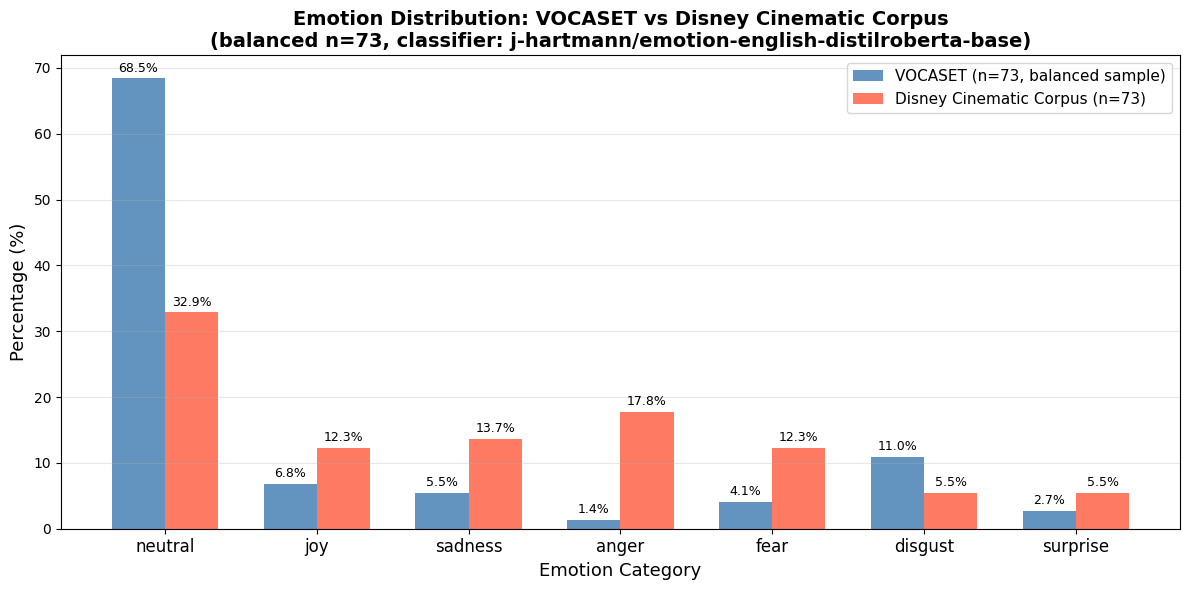

✓ Chart saved


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Balance datasets to same size
n = len(df_disney)  # 73

df_voca_balanced = df_voca_dedup.sample(n=n, random_state=42).reset_index(drop=True)

print(f"VOCASET balanced: {len(df_voca_balanced)}")
print(f"Disney corpus:    {len(df_disney)}")

# Normalized distributions
voca_dist_bal   = df_voca_balanced['top_emotion'].value_counts(normalize=True) * 100
disney_dist_bal = df_disney['top_emotion'].value_counts(normalize=True) * 100

print("\nVOCASET (balanced) %:")
print(voca_dist_bal.round(1))
print("\nDisney %:")
print(disney_dist_bal.round(1))

# Plot
emotion_labels = ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']

voca_vals   = [voca_dist_bal.get(e, 0)   for e in emotion_labels]
disney_vals = [disney_dist_bal.get(e, 0) for e in emotion_labels]

x = np.arange(len(emotion_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, voca_vals,   width, label=f'VOCASET (n={n}, balanced sample)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, disney_vals, width, label=f'Disney Cinematic Corpus (n={n})',   color='tomato',    alpha=0.85)

ax.set_xlabel('Emotion Category', fontsize=13)
ax.set_ylabel('Percentage (%)', fontsize=13)
ax.set_title('Emotion Distribution: VOCASET vs Disney Cinematic Corpus\n(balanced n=73, classifier: j-hartmann/emotion-english-distilroberta-base)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(emotion_labels, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('emotion_distribution_comparison_balanced.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

---
## 4. Human-Model Agreement Analysis

We compare the automated classifier predictions against human annotations on the DCC.
Since human labels are fine-grained (e.g., `betrayal`, `manipulation`), we map them
to the 7 Ekman categories before computing agreement.

In [ ]:
# Mapping from fine-grained human labels to Ekman 7 categories
label_mapping = {
    # neutral
    'irony': 'neutral',
    'deflection': 'neutral',
    'cold': 'neutral',
    'cold_calculation': 'neutral',
    'cold_villainy': 'neutral',
    'authority': 'neutral',
    'wisdom': 'neutral',
    'warmth': 'neutral',
    'reassurance': 'neutral',
    'innocence': 'neutral',
    'control': 'neutral',
    'protective': 'neutral',

    # joy
    'joy': 'joy',
    'excitement': 'joy',
    'tenderness': 'joy',
    'nostalgia': 'joy',
    'wonder': 'joy',

    # sadness
    'sadness': 'sadness',
    'grief': 'sadness',
    'melancholy': 'sadness',
    'longing': 'sadness',
    'regret': 'sadness',
    'guilt': 'sadness',
    'vulnerability': 'sadness',
    'loneliness': 'sadness',
    'hidden_pain': 'sadness',
    'numbness': 'sadness',
    'self_sacrifice': 'sadness',
    'heartbreak': 'sadness',
    'pleading': 'sadness',

    # anger
    'anger': 'anger',
    'defiance': 'anger',
    'frustration': 'anger',
    'repressed_anger': 'anger',
    'injustice': 'anger',
    'confrontation': 'anger',

    # fear
    'fear': 'fear',
    'anxiety': 'fear',
    'panic': 'fear',
    'protective_fear': 'fear',
    'desperation': 'fear',
    'repression': 'fear',

    # disgust
    'disgust': 'disgust',
    'manipulation': 'disgust',
    'gaslighting': 'disgust',

    # surprise
    'surprise': 'surprise',
    'shock': 'surprise',
    'realization': 'surprise',
    'inner_conflict': 'surprise',

    # fallback
    'determination': 'neutral',
    'inadequacy': 'sadness',
    'exclusion': 'sadness',
    'pressure': 'fear',
    'self_doubt': 'sadness',
    'suppressed_sadness': 'sadness',
    'emotional_release': 'sadness',
    'empathy': 'neutral',
    'protective_love': 'neutral',
    'hidden_pain': 'sadness',
    'denial': 'neutral',
}

# Apply mapping
df_disney['emotion_label_ekman'] = df_disney['emotion_label'].map(label_mapping)

# Check unmapped
unmapped = df_disney[df_disney['emotion_label_ekman'].isna()]['emotion_label'].unique()
if len(unmapped) > 0:
    print(f"⚠ Unmapped labels: {unmapped}")
else:
    print("✓ All labels mapped")

# Compute agreement
df_disney['correct'] = df_disney['emotion_label_ekman'] == df_disney['top_emotion']
accuracy = df_disney['correct'].mean() * 100
print(f"\nOverall agreement (human vs model): {accuracy:.1f}%")
print(f"Correct: {df_disney['correct'].sum()} / {len(df_disney)}")

⚠ Unmapped labels: ['betrayal' 'sarcasm' 'inspiration' 'breakdown']

Overall agreement (human vs model): 28.8%
Correct: 21 / 73


### 4.1 Complete label mapping and agreement computation
The first pass leaves 4 labels unmapped (betrayal, sarcasm, inspiration, breakdown).
These are added in the next cell, after which agreement rises from 28.8% to 31.5%.

Unmapped: []

Overall agreement: 31.5%
Correct: 23 / 73

--- DISAGREEMENTS ---
[Frozen] Hans
  Human: betrayal → disgust | Model: surprise
  Text: Oh Anna. If only there was someone out there who loved you....

[Frozen] Anna
  Human: desperation → fear | Model: sadness
  Text: Elsa, please. Please. I can't live like this anymore....

[Frozen] Anna
  Human: heartbreak → sadness | Model: anger
  Text: What did I ever do to you?! Why do you shut me out? Why do you shut the world ou...

[Frozen] Elsa
  Human: vulnerability → sadness | Model: neutral
  Text: ...Then leave....

[Frozen] Elsa
  Human: repression → fear | Model: anger
  Text: Conceal. Don't feel. Put on a show. Make one wrong move and everyone will know....

[Frozen] Anna
  Human: loneliness → sadness | Model: neutral
  Text: We only have each other. It's just you and me. What are we gonna do?...

[Frozen] Elsa
  Human: anger → anger | Model: neutral
  Text: You can't marry a man you just met....

[Frozen] Anna
  Human: defian

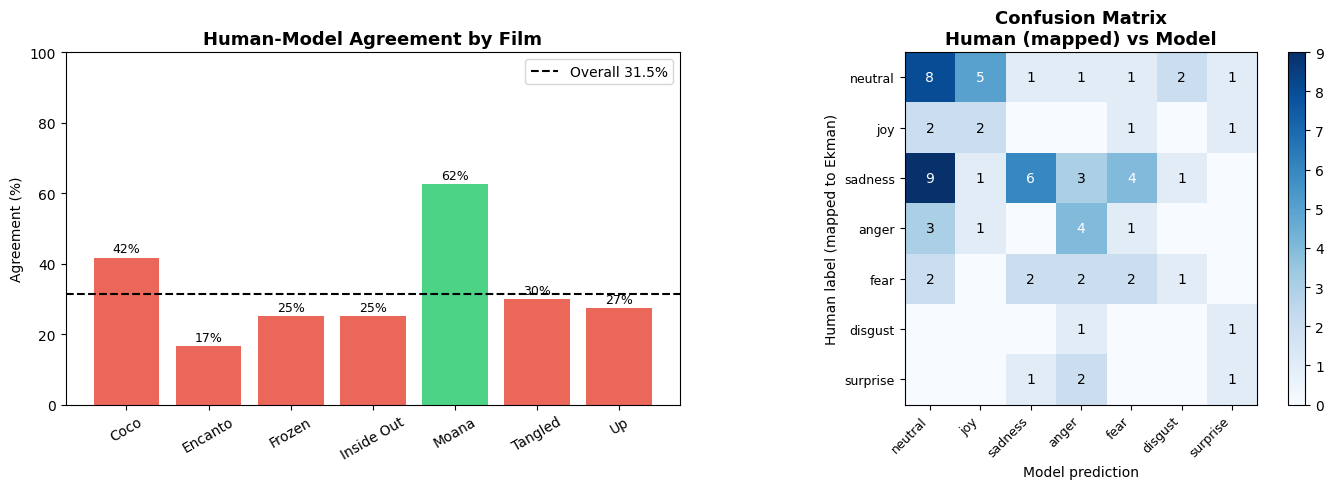

✓ Saved


In [ ]:
# Add missing mappings
label_mapping.update({
    'betrayal': 'disgust',
    'sarcasm': 'neutral',
    'inspiration': 'joy',
    'breakdown': 'sadness',
})

# Reapply
df_disney['emotion_label_ekman'] = df_disney['emotion_label'].map(label_mapping)

unmapped = df_disney[df_disney['emotion_label_ekman'].isna()]['emotion_label'].unique()
print(f"Unmapped: {unmapped}")

df_disney['correct'] = df_disney['emotion_label_ekman'] == df_disney['top_emotion']
accuracy = df_disney['correct'].mean() * 100
print(f"\nOverall agreement: {accuracy:.1f}%")
print(f"Correct: {df_disney['correct'].sum()} / {len(df_disney)}")

# Show disagreements
print("\n--- DISAGREEMENTS ---")
wrong = df_disney[~df_disney['correct']][['film','character','emotion_label','emotion_label_ekman','top_emotion','text']]
for _, row in wrong.iterrows():
    print(f"[{row['film']}] {row['character']}")
    print(f"  Human: {row['emotion_label']} → {row['emotion_label_ekman']} | Model: {row['top_emotion']}")
    print(f"  Text: {row['text'][:80]}...")
    print()

# Plot agreement by film
import matplotlib.pyplot as plt

film_accuracy = df_disney.groupby('film')['correct'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: agreement by film
colors = ['#2ecc71' if v >= 50 else '#e74c3c' for v in film_accuracy.values]
axes[0].bar(film_accuracy.index, film_accuracy.values, color=colors, alpha=0.85)
axes[0].axhline(y=accuracy, color='black', linestyle='--', linewidth=1.5, label=f'Overall {accuracy:.1f}%')
axes[0].set_title('Human-Model Agreement by Film', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Agreement (%)')
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(film_accuracy.values):
    axes[0].text(i, v + 1.5, f'{v:.0f}%', ha='center', fontsize=9)

# Right: confusion heatmap human_ekman vs model
import pandas as pd
ekman_cats = ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']
confusion = pd.crosstab(
    df_disney['emotion_label_ekman'],
    df_disney['top_emotion'],
    rownames=['Human (mapped)'],
    colnames=['Model'],
).reindex(index=ekman_cats, columns=ekman_cats, fill_value=0)

im = axes[1].imshow(confusion.values, cmap='Blues')
axes[1].set_xticks(range(len(ekman_cats)))
axes[1].set_yticks(range(len(ekman_cats)))
axes[1].set_xticklabels(ekman_cats, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(ekman_cats, fontsize=9)
axes[1].set_title('Confusion Matrix\nHuman (mapped) vs Model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Model prediction')
axes[1].set_ylabel('Human label (mapped to Ekman)')

for i in range(len(ekman_cats)):
    for j in range(len(ekman_cats)):
        val = confusion.values[i, j]
        if val > 0:
            axes[1].text(j, i, str(val), ha='center', va='center',
                        color='white' if val > 3 else 'black', fontsize=10)

plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig('agreement_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")

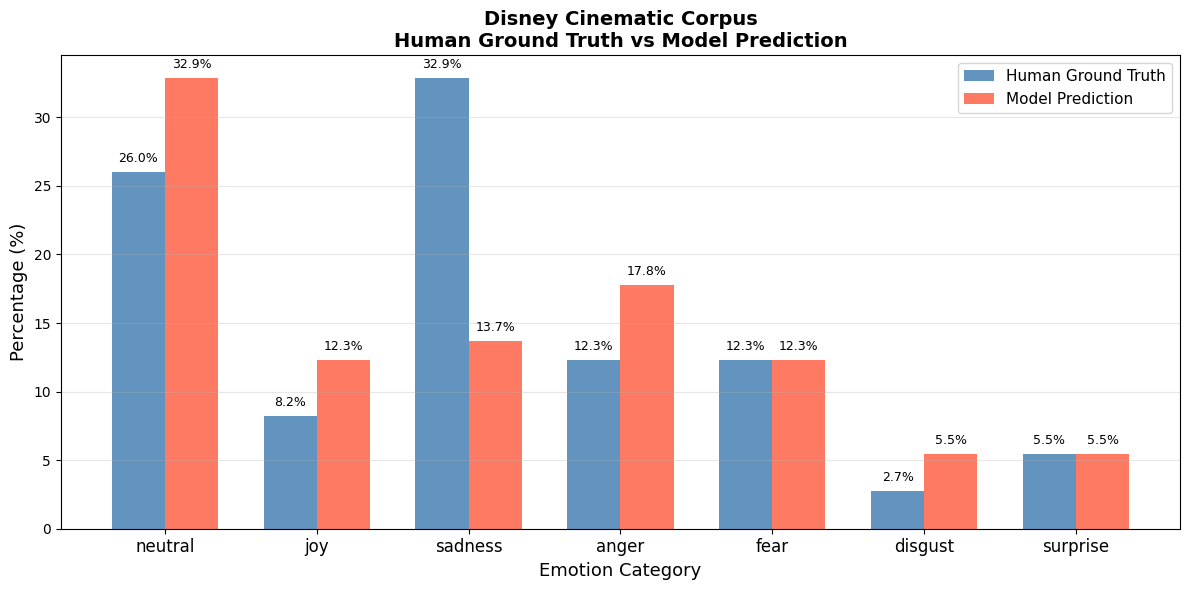

✓ Saved


In [ ]:
ekman_cats = ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']

ground_truth = df_disney['emotion_label_ekman'].value_counts(normalize=True) * 100
model_pred   = df_disney['top_emotion'].value_counts(normalize=True) * 100

gt_vals    = [ground_truth.get(e, 0) for e in ekman_cats]
model_vals = [model_pred.get(e, 0)   for e in ekman_cats]

x = np.arange(len(ekman_cats))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, gt_vals,    width, label='Human Ground Truth', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, model_vals, width, label='Model Prediction',   color='tomato',    alpha=0.85)

ax.set_xlabel('Emotion Category', fontsize=13)
ax.set_ylabel('Percentage (%)', fontsize=13)
ax.set_title('Disney Cinematic Corpus\nHuman Ground Truth vs Model Prediction', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ekman_cats, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('ground_truth_vs_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")